# Baseline — unigram+bigram at 700k / 1.5M / 3.6M

Only the winning configuration (unigram+bigram) is run. `C`, `MIN_DF`, `MAX_FEATURES`,
solver and seed are held at the baseline values, so sample size is the only variable.

One streaming pass over `train.csv` per size; only one size is held in memory at a time.


## Setup

In [1]:
from pathlib import Path
import gc
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import joblib
from scipy import sparse

# ============================================================
# REPRODUCIBILITY -- REPLACE THIS WITH YOUR OWN DATA PATH.
# Point it at the folder holding the Amazon Polarity CSVs.
# That folder must contain: train.csv and test.csv
# Everything else in this notebook is relative to the notebook
# directory (artifacts/, results_csv/) and needs no editing.
# ============================================================
# Same folder from either kernel: Windows Python sees C:\..., WSL sees /mnt/c/...
_WIN = Path(r"C:\Users\bsarv\Fake Desktop\amz sentiment analysis\archive")
_WSL = Path("/mnt/c/Users/bsarv/Fake Desktop/amz sentiment analysis/archive")
DATA_DIR = _WIN if _WIN.exists() else _WSL
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

# Matrices, vectorisers and models are written here so nothing is vectorised twice.
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

COLUMN_NAMES = ["label", "title", "text"]

SEED = 42
CHUNK = 100_000
N_CHUNKS = 36
TOTAL_ROWS = 3_600_000

VAL_SIZE = 0.2
MIN_DF = 5
MAX_FEATURES = 50_000
NGRAM_RANGE = (1, 2)

# Set from the exploration_and_experiments.ipynb regularisation sweep (unigram+bigram row).
BEST_C = 2.5

SIZES = [700_000, 1_500_000, TOTAL_ROWS]

# unigram+bigram results already measured in exploration_and_experiments.ipynb, for the combined curve.
PRIOR = {
    20_000: 0.9056,
    40_000: 0.9063,
    80_000: 0.9170,
    160_000: 0.9234,
    400_000: 0.9291,
}

RESULTS_DIR = Path("results_csv")
RESULTS_DIR.mkdir(exist_ok=True)

# Run All is idempotent. Every expensive step below checks for its own output first
# and only computes what is missing, so a fresh machine builds everything and a
# machine that already has the artifacts goes straight to scoring.
FORCE_REBUILD = False

ARTIFACT_PARTS = [
    "Xtr_{}.npz", "Xva_{}.npz", "ytr_{}.npy",
    "yva_{}.npy", "vec_{}.joblib", "model_{}.joblib",
]


def artifacts_exist(size):
    """True when section 2 has already produced everything for this size."""
    return all((ARTIFACT_DIR / part.format(size)).exists() for part in ARTIFACT_PARTS)


def cached(path):
    """True when a result file is on disk and no rebuild was forced."""
    return Path(path).exists() and not FORCE_REBUILD


print("data:", DATA_DIR)
print("artifacts present:", {s: artifacts_exist(s) for s in SIZES})


data: C:\Users\bsarv\Fake Desktop\amz sentiment analysis\archive
artifacts present: {700000: True, 1500000: True, 3600000: True}


## 1. Sampling

`load_sample(n)` makes one pass over the file and takes `n / 2 / 36` rows of each class
from every chunk, so the sample is spread across the whole file rather than its opening rows.

At `n = TOTAL_ROWS` there is nothing to sample: the whole file is read as-is.

In [2]:
def load_sample(n):
    """One streaming pass -> (texts, labels) balanced across classes and chunks."""
    rng = np.random.default_rng(SEED)
    take = -(-(n // 2) // N_CHUNKS)      # rows per class per chunk (ceil)
    full = n >= TOTAL_ROWS
    parts = []

    t0 = time.perf_counter()

    for chunk in pd.read_csv(
        TRAIN_PATH,
        header=None,
        names=COLUMN_NAMES,
        dtype={"label": "int8"},
        keep_default_na=False,
        chunksize=CHUNK
    ):
        chunk["combined"] = (chunk["title"] + " " + chunk["text"]).str.strip()
        chunk = chunk[["label", "combined"]]

        if full:
            parts.append(chunk)
            continue

        for label in (1, 2):
            rows = chunk[chunk["label"] == label]
            parts.append(rows.sample(
                n=min(take, len(rows)),
                random_state=rng.integers(1e9)
            ))

    sample = pd.concat(parts, ignore_index=True)
    del parts
    gc.collect()

    if not full:
        sample = sample.groupby("label", group_keys=False).head(n // 2)

    sample = sample.sample(frac=1, random_state=SEED).reset_index(drop=True)

    read_seconds = time.perf_counter() - t0
    print(
        f"loaded {len(sample)} rows in {read_seconds:.1f}s  "
        f"balance={np.bincount(sample['label'].to_numpy())[1:]}  "
        f"memory={sample.memory_usage(deep=True).sum() / 1e6:.0f} MB"
    )

    texts = sample["combined"].tolist()
    labels = sample["label"].to_numpy()

    del sample
    gc.collect()

    return texts, labels


## 2. Runs

Same procedure per size: 80/20 stratified split, TF-IDF fitted on train only, one
logistic-regression fit at `BEST_C`. Everything for a size is freed before the next one starts.

In [3]:
RESULTS_CSV = RESULTS_DIR / "baseline_full_results.csv"
BUILD = [s for s in SIZES if FORCE_REBUILD or not artifacts_exist(s)]

if not BUILD:
    print("artifacts present for every size - skipping the build")
    full_df = pd.read_csv(RESULTS_CSV)
else:
    print("building:", BUILD)
    results = []

    for size in BUILD:
        print("=" * 60)
        print(f"size = {size}")
        print("=" * 60)

        texts, labels = load_sample(size)

        X_train, X_val, y_train, y_val = train_test_split(
            texts, labels,
            test_size=VAL_SIZE,
            random_state=SEED,
            stratify=labels
        )

        del texts, labels
        gc.collect()

        vec = TfidfVectorizer(
            ngram_range=NGRAM_RANGE,
            min_df=MIN_DF,
            max_features=MAX_FEATURES
        )

        t0 = time.perf_counter()
        Xtr = vec.fit_transform(X_train)     # fit ONLY on train
        Xva = vec.transform(X_val)           # val uses train's vocabulary
        vec_seconds = time.perf_counter() - t0

        # Saved before anything is freed. Reloading these costs seconds instead of
        # re-vectorising, which is the expensive half of the run.
        sparse.save_npz(ARTIFACT_DIR / f"Xtr_{size}.npz", Xtr)
        sparse.save_npz(ARTIFACT_DIR / f"Xva_{size}.npz", Xva)
        np.save(ARTIFACT_DIR / f"ytr_{size}.npy", y_train)
        np.save(ARTIFACT_DIR / f"yva_{size}.npy", y_val)
        joblib.dump(vec, ARTIFACT_DIR / f"vec_{size}.joblib")

        del X_train, X_val
        gc.collect()

        model = LogisticRegression(C=BEST_C, max_iter=1000, solver="liblinear")

        t0 = time.perf_counter()
        model.fit(Xtr, y_train)
        fit_seconds = time.perf_counter() - t0

        joblib.dump(model, ARTIFACT_DIR / f"model_{size}.joblib")

        pred = model.predict(Xva)

        results.append({
            "sample_size": size,
            "C": BEST_C,
            "train_rows": Xtr.shape[0],
            "features": "unigram+bigram",
            "vocab": Xtr.shape[1],
            "train_accuracy": accuracy_score(y_train, model.predict(Xtr)),
            "validation_accuracy": accuracy_score(y_val, pred),
            "validation_f1": f1_score(y_val, pred, pos_label=2),
            "iterations": model.n_iter_[0],
            "vectorize_seconds": round(vec_seconds, 1),
            "fit_seconds": round(fit_seconds, 1),
            "matrix_mb": round(
                (Xtr.data.nbytes + Xtr.indices.nbytes + Xtr.indptr.nbytes) / 1e6, 1
            ),
        })

        print(f"val={results[-1]['validation_accuracy']:.4f} "
              f"vocab={Xtr.shape[1]} vec={vec_seconds:.1f}s fit={fit_seconds:.1f}s "
              f"matrix={results[-1]['matrix_mb']:.0f} MB")

        print("\n", classification_report(
            y_val, pred, target_names=["negative", "positive"], digits=4
        ))

        print(pd.DataFrame(
            confusion_matrix(y_val, pred),
            index=["true neg", "true pos"],
            columns=["pred neg", "pred pos"]
        ), "\n")

        del Xtr, Xva, vec, model, pred, y_train, y_val
        gc.collect()

    fresh = pd.DataFrame(results)

    # Rebuilt sizes replace their old rows; sizes that were skipped are kept.
    if RESULTS_CSV.exists():
        kept = pd.read_csv(RESULTS_CSV)
        kept = kept[~kept["sample_size"].isin(fresh["sample_size"])]
        full_df = pd.concat([kept, fresh], ignore_index=True)
    else:
        full_df = fresh

    full_df = full_df.sort_values("sample_size").reset_index(drop=True)
    full_df.to_csv(RESULTS_CSV, index=False)

full_df


artifacts present for every size - skipping the build


,sample_size,C,train_rows,features,vocab,train_accuracy,validation_accuracy,validation_f1,iterations,vectorize_seconds,fit_seconds,matrix_mb
0,700000,2.5,560000,unigram+bigram,50000,0.949139,0.932671,0.932639,7,125.0,29.9,620.3
1,1500000,2.5,1200000,unigram+bigram,50000,0.946827,0.936733,0.936764,8,232.9,86.9,1328.5
2,3600000,2.5,2880000,unigram+bigram,50000,0.945016,0.939650,0.939670,8,754.1,233.5,3186.9


## 3. Combined learning curve

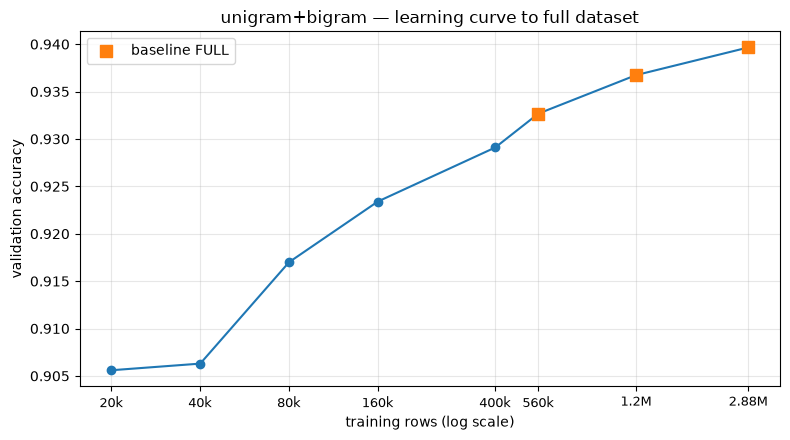

In [14]:
combined = pd.concat([
    pd.DataFrame({
        "train_rows": list(PRIOR.keys()),
        "validation_accuracy": list(PRIOR.values()),
        "source": "exploration_and_experiments.ipynb",
    }),
    full_df[["train_rows", "validation_accuracy"]].assign(source="baseline FULL"),
], ignore_index=True).sort_values("train_rows")


def row_label(n):
    """20000 -> '20k', 1200000 -> '1.2M'. Ticks sit on the measured sizes."""
    if n >= 1_000_000:
        return f"{n / 1_000_000:g}M"
    return f"{n / 1_000:g}k"


fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(combined["train_rows"], combined["validation_accuracy"], marker="o", color="C0")

for src, marker in [("baseline FULL", "s")]:
    part = combined[combined["source"] == src]
    ax.scatter(part["train_rows"], part["validation_accuracy"],
               marker=marker, s=70, color="C1", zorder=3, label=src)

ax.set_xscale("log")

# Tick only where a model was actually trained, rather than at powers of ten.
ticks = combined["train_rows"].tolist()
ax.set_xticks(ticks)
ax.set_xticklabels([row_label(n) for n in ticks])
ax.set_xticks([], minor=True)          # kill the 2x/3x/5x minor decade ticks
ax.tick_params(axis="x", labelsize=9)

ax.set_xlabel("training rows (log scale)")
ax.set_ylabel("validation accuracy")
ax.set_title("unigram+bigram — learning curve to full dataset")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


In [5]:
# Marginal return per step up in training size.
prev = None

for rows, acc in zip(combined["train_rows"], combined["validation_accuracy"]):
    step = "" if prev is None else f"  ({(acc - prev) * 100:+.2f} pts)"
    print(f"  {rows:>9} rows  {acc:.4f}{step}")
    prev = acc


      20000 rows  0.9056
      40000 rows  0.9063  (+0.07 pts)
      80000 rows  0.9170  (+1.07 pts)
     160000 rows  0.9234  (+0.64 pts)
     400000 rows  0.9291  (+0.57 pts)
     560000 rows  0.9327  (+0.36 pts)
    1200000 rows  0.9367  (+0.41 pts)
    2880000 rows  0.9396  (+0.29 pts)


## 4. Reloading/Future re-runs

Everything each size produced is on disk under `artifacts/`. Nothing above needs to run again.

`vectorize_seconds` is roughly three quarters of the cost of a size, so reloading the matrix
is what makes a second experiment at full scale affordable — a new `C` costs only the fit.

In [6]:
def load_artifacts(size):
    """Reload one size. Returns (vec, model, Xtr, Xva, y_train, y_val)."""
    return (
        joblib.load(ARTIFACT_DIR / f"vec_{size}.joblib"),
        joblib.load(ARTIFACT_DIR / f"model_{size}.joblib"),
        sparse.load_npz(ARTIFACT_DIR / f"Xtr_{size}.npz"),
        sparse.load_npz(ARTIFACT_DIR / f"Xva_{size}.npz"),
        np.load(ARTIFACT_DIR / f"ytr_{size}.npy"),
        np.load(ARTIFACT_DIR / f"yva_{size}.npy"),
    )


for f in sorted(ARTIFACT_DIR.iterdir()):
    print(f"{f.name:<28} {f.stat().st_size / 1e6:>8.1f} MB")


model_1500000.joblib              0.4 MB
model_3600000.joblib              0.4 MB
model_700000.joblib               0.4 MB
vec_1500000.joblib                1.9 MB
vec_3600000.joblib                1.9 MB
vec_700000.joblib                 1.9 MB
Xte_1500000.npz                 347.2 MB
Xte_3600000.npz                 347.5 MB
Xte_700000.npz                  346.6 MB
Xtr_1500000.npz                1064.1 MB
Xtr_3600000.npz                2554.6 MB
Xtr_700000.npz                  496.1 MB
Xva_1500000.npz                 260.9 MB
Xva_3600000.npz                 626.8 MB
Xva_700000.npz                  121.7 MB
yte.npy                           0.4 MB
ytr_1500000.npy                   1.2 MB
ytr_3600000.npy                   2.9 MB
ytr_700000.npy                    0.6 MB
yva_1500000.npy                   0.3 MB
yva_3600000.npy                   0.7 MB
yva_700000.npy                    0.1 MB


## 5. Final baseline — reload and score

The baseline of record is **`max_features=50_000`**: it is the configuration the whole
learning curve, the `C` sweep and the fastText comparison were built on. Section 8's
100,000-feature runs are a measured appendix showing that ceiling was binding, not a
replacement for it.

Nothing here trains. Every model, vectoriser and matrix is already in `artifacts/` from
section 2, so this section reloads them and reports validation and test together.

The test matrices are built once and cached the same way. Each size is transformed with
**its own** vectoriser — `transform`, never `fit_transform`, since fitting a vectoriser on
the test set would leak it.


In [11]:
# One-time: transform test.csv with each size's own vectoriser, then cache.
yte_path = ARTIFACT_DIR / "yte.npy"
need = [s for s in SIZES if not (ARTIFACT_DIR / f"Xte_{s}.npz").exists()]

if need or not yte_path.exists():
    test = pd.read_csv(
        TEST_PATH,
        header=None,
        names=COLUMN_NAMES,
        dtype={"label": "int8"},
        keep_default_na=False
    )

    test_texts = (test["title"] + " " + test["text"]).str.strip().tolist()
    y_test = test["label"].to_numpy()

    del test
    gc.collect()

    np.save(yte_path, y_test)
    print(f"test: {len(y_test)} rows, balance={np.bincount(y_test)[1:]}")

    for size in need:
        vec = joblib.load(ARTIFACT_DIR / f"vec_{size}.joblib")

        t0 = time.perf_counter()
        Xte = vec.transform(test_texts)          # transform only - no refit
        sparse.save_npz(ARTIFACT_DIR / f"Xte_{size}.npz", Xte)

        print(f"  cached Xte_{size}.npz  {Xte.shape}  {time.perf_counter() - t0:.1f}s")

        del vec, Xte
        gc.collect()

    del test_texts
    gc.collect()
else:
    print("all test matrices already cached - nothing to build")


all test matrices already cached - nothing to build


In [12]:
# Pure reload. No fitting, no vectorising, no read of train.csv.
FINAL_SIZE = max(SIZES)
y_test = np.load(ARTIFACT_DIR / "yte.npy")

rows = []
final_pred = None

for size in SIZES:
    model = joblib.load(ARTIFACT_DIR / f"model_{size}.joblib")
    Xva = sparse.load_npz(ARTIFACT_DIR / f"Xva_{size}.npz")
    yva = np.load(ARTIFACT_DIR / f"yva_{size}.npy")
    Xte = sparse.load_npz(ARTIFACT_DIR / f"Xte_{size}.npz")

    pred_val = model.predict(Xva)
    pred_test = model.predict(Xte)

    rows.append({
        "sample_size": size,
        "train_rows": len(np.load(ARTIFACT_DIR / f"ytr_{size}.npy")),
        "vocab": Xva.shape[1],
        "validation_accuracy": accuracy_score(yva, pred_val),
        "validation_f1": f1_score(yva, pred_val, average="macro"),
        "test_accuracy": accuracy_score(y_test, pred_test),
        "test_f1": f1_score(y_test, pred_test, average="macro"),
    })

    if size == FINAL_SIZE:
        final_pred = pred_test

    del model, Xva, yva, Xte, pred_val, pred_test
    gc.collect()

final_df = pd.DataFrame(rows)

# Close to zero means the validation split was not flattering the model.
final_df["val_minus_test"] = (
    final_df["validation_accuracy"] - final_df["test_accuracy"]
).round(5)

final_df.to_csv("results_csv/baseline_final.csv", index=False)
print(final_df.to_string(index=False))


 sample_size  train_rows  vocab  validation_accuracy  validation_f1  test_accuracy  test_f1  val_minus_test
      700000      560000  50000             0.932671       0.932671       0.932865 0.932865        -0.00019
     1500000     1200000  50000             0.936733       0.936733       0.936268 0.936267         0.00047
     3600000     2880000  50000             0.939650       0.939650       0.939375 0.939375         0.00028


## Headline

In [13]:
# Headline: the largest model, on the untouched 400k test set.
head = final_df[final_df["sample_size"] == FINAL_SIZE].iloc[0]

print("FINAL BASELINE")
print(f"  TF-IDF ngram={NGRAM_RANGE} min_df={MIN_DF} max_features={MAX_FEATURES}")
print(f"  LogisticRegression C={BEST_C} solver=liblinear")
print(f"  trained on {int(head['train_rows']):,} rows, {int(head['vocab']):,} features")
print()
print(f"  validation accuracy  {head['validation_accuracy']:.6f}")
print(f"  test accuracy        {head['test_accuracy']:.6f}")
print(f"  test macro F1        {head['test_f1']:.6f}")
print(f"  val - test           {head['val_minus_test']:+.5f}")
print()

# Macro F1 is reported next to accuracy because the test set is 200k/200k balanced -
# on balanced classes the two agree, and that agreement is itself the check.
print(classification_report(
    y_test, final_pred, target_names=["negative", "positive"], digits=4
))

print(pd.DataFrame(
    confusion_matrix(y_test, final_pred),
    index=["true negative", "true positive"],
    columns=["pred negative", "pred positive"]
))


FINAL BASELINE
  TF-IDF ngram=(1, 2) min_df=5 max_features=50000
  LogisticRegression C=2.5 solver=liblinear
  trained on 2,880,000 rows, 50,000 features

  validation accuracy  0.939650
  test accuracy        0.939375
  test macro F1        0.939375
  val - test           +0.00028

              precision    recall  f1-score   support

    negative     0.9400    0.9386    0.9393    200000
    positive     0.9387    0.9401    0.9394    200000

    accuracy                         0.9394    400000
   macro avg     0.9394    0.9394    0.9394    400000
weighted avg     0.9394    0.9394    0.9394    400000

               pred negative  pred positive
true negative         187729          12271
true positive          11979         188021


## Does `max_features` bind?

`MAX_FEATURES = 50_000` was held fixed everywhere and never varied. The sweep in
`exploration_and_experiments.ipynb` shows the unigram+bigram vocabulary hitting exactly
50,000 from 50k rows upward - the cap is reached at every size run here, so the feature
count is set by the ceiling, not by the data.

This doubles the ceiling to 100,000 and changes nothing else: same `load_sample`, same
seed and split, same `MIN_DF`, same `NGRAM_RANGE`, same `BEST_C`. Only 700k and 1.5M are
run - 3.6M costs 754s to vectorise and the two smaller sizes answer the question.

Read `val_delta`. If it is ~0 the cap is not costing accuracy and 50,000 is justified by
measurement rather than assumption. If it is positive, feature capacity is a live lever
the baseline never pulled.


In [15]:
BIG_CSV = RESULTS_DIR / "baseline_maxfeatures_100k.csv"

if cached(BIG_CSV):
    big_df = pd.read_csv(BIG_CSV)
    print(f"cached - {BIG_CSV.name}, not re-run")
else:
    MAX_FEATURES_BIG = 100_000
    SIZES_BIG = [700_000, 1_500_000]

    big = []

    for size in SIZES_BIG:
        print("=" * 60)
        print(f"size = {size}   max_features = {MAX_FEATURES_BIG}")
        print("=" * 60)

        texts, labels = load_sample(size)

        X_train, X_val, y_train, y_val = train_test_split(
            texts, labels,
            test_size=VAL_SIZE,
            random_state=SEED,
            stratify=labels
        )

        del texts, labels
        gc.collect()

        # Only max_features differs from section 2.
        vec = TfidfVectorizer(
            ngram_range=NGRAM_RANGE,
            min_df=MIN_DF,
            max_features=MAX_FEATURES_BIG
        )

        t0 = time.perf_counter()
        Xtr = vec.fit_transform(X_train)
        Xva = vec.transform(X_val)
        vec_seconds = time.perf_counter() - t0

        del X_train, X_val
        gc.collect()

        model = LogisticRegression(C=BEST_C, max_iter=1000, solver="liblinear")

        t0 = time.perf_counter()
        model.fit(Xtr, y_train)
        fit_seconds = time.perf_counter() - t0

        pred = model.predict(Xva)

        big.append({
            "sample_size": size,
            "max_features": MAX_FEATURES_BIG,
            "train_rows": Xtr.shape[0],
            "vocab": Xtr.shape[1],
            "train_accuracy": accuracy_score(y_train, model.predict(Xtr)),
            "validation_accuracy": accuracy_score(y_val, pred),
            "validation_f1": f1_score(y_val, pred, pos_label=2),
            "vectorize_seconds": round(vec_seconds, 1),
            "fit_seconds": round(fit_seconds, 1),
            "matrix_mb": round(
                (Xtr.data.nbytes + Xtr.indices.nbytes + Xtr.indptr.nbytes) / 1e6, 1
            ),
        })

        print(f"val={big[-1]['validation_accuracy']:.4f} vocab={Xtr.shape[1]} "
              f"vec={vec_seconds:.1f}s fit={fit_seconds:.1f}s "
              f"matrix={big[-1]['matrix_mb']:.0f} MB")

        del Xtr, Xva, vec, model, pred, y_train, y_val
        gc.collect()

    big_df = pd.DataFrame(big)
    big_df.to_csv("results_csv/baseline_maxfeatures_100k.csv", index=False)

big_df


cached - baseline_maxfeatures_100k.csv, not re-run


,sample_size,max_features,train_rows,vocab,train_accuracy,validation_accuracy,validation_f1,vectorize_seconds,fit_seconds,matrix_mb
0,700000,100000,560000,100000,0.955270,0.933721,0.933675,196.8,38.0,663.7
1,1500000,100000,1200000,100000,0.953043,0.938670,0.938703,255.3,93.8,1421.1


In [16]:
# 50,000 vs 100,000 at the same sizes. base_50k comes from section 2.
base_50k = pd.read_csv("results_csv/baseline_full_results.csv")

compare = (
    big_df[["sample_size", "vocab", "validation_accuracy", "vectorize_seconds",
            "fit_seconds", "matrix_mb"]]
    .merge(
        base_50k[["sample_size", "vocab", "validation_accuracy", "vectorize_seconds",
                  "fit_seconds", "matrix_mb"]],
        on="sample_size",
        suffixes=("_100k", "_50k")
    )
)

compare["val_delta_pts"] = (
    (compare["validation_accuracy_100k"] - compare["validation_accuracy_50k"]) * 100
).round(3)

compare["vectorize_cost_x"] = (
    compare["vectorize_seconds_100k"] / compare["vectorize_seconds_50k"]
).round(2)

compare["memory_cost_x"] = (
    compare["matrix_mb_100k"] / compare["matrix_mb_50k"]
).round(2)

print(compare[["sample_size", "vocab_50k", "vocab_100k",
               "validation_accuracy_50k", "validation_accuracy_100k",
               "val_delta_pts", "vectorize_cost_x", "memory_cost_x"]].to_string(index=False))

compare.to_csv("results_csv/baseline_maxfeatures_comparison.csv", index=False)


 sample_size  vocab_50k  vocab_100k  validation_accuracy_50k  validation_accuracy_100k  val_delta_pts  vectorize_cost_x  memory_cost_x
      700000      50000      100000                 0.932671                  0.933721          0.105              1.57           1.07
     1500000      50000      100000                 0.936733                  0.938670          0.194              1.10           1.07


## Re-sweeping C at full size

In [17]:
SWEEP_SIZE = TOTAL_ROWS
SWEEP_C = [1.5, 2.0, 2.5, 3.0, 3.5]
SWEEP_CSV = RESULTS_DIR / f"sweep_C_{SWEEP_SIZE}.csv"

if cached(SWEEP_CSV):
    sweep_full_df = pd.read_csv(SWEEP_CSV)
    print(f"cached - {SWEEP_CSV.name}, not re-swept")
else:
    _, _, Xtr, Xva, ytr, yva = load_artifacts(SWEEP_SIZE)
    print(f"reloaded {Xtr.shape[0]} x {Xtr.shape[1]}")

    sweep = []

    for c_value in SWEEP_C:
        m = LogisticRegression(C=c_value, max_iter=1000, solver="liblinear")

        t0 = time.perf_counter()
        m.fit(Xtr, ytr)
        fit_seconds = time.perf_counter() - t0

        pred = m.predict(Xva)

        sweep.append({
            "C": c_value,
            "validation_accuracy": accuracy_score(yva, pred),
            "validation_f1": f1_score(yva, pred, pos_label=2),
            "fit_seconds": round(fit_seconds, 1),
        })

        print(f"C={c_value:<5} val={sweep[-1]['validation_accuracy']:.4f} "
              f"fit={fit_seconds:.1f}s")

        del m, pred
        gc.collect()

    del Xtr, Xva, ytr, yva
    gc.collect()

    sweep_full_df = pd.DataFrame(sweep)
    sweep_full_df.to_csv(SWEEP_CSV, index=False)

sweep_full_df


cached - sweep_C_3600000.csv, not re-swept


,C,validation_accuracy,validation_f1,fit_seconds
0,1.5,0.939364,0.939380,221.2
1,2.0,0.939601,0.939622,241.8
2,2.5,0.939650,0.939670,232.7
3,3.0,0.939617,0.939638,247.7
4,3.5,0.939619,0.939640,243.4


## Runtime Considerations with limited resouces

- **Training-set size:** The learning curve showed a clear trade-off between accuracy and computational cost. With unigram+bigram features:

  - 50k: **90.63%**, 6.6 s vec, 1.1 s fitting, 44.6 MB
  - 100k: **91.70%**, 13.2 s vec, 2.5 s fitting, 88.9 MB
  - 200k: **92.34%**, 29.0 s vec, 7.0 s fitting, 177.4 MB
  - 700k: **93.27%**, 125.0 s vec, 29.9 s fitting, 620.3 MB
  - 1.5M: **93.67%**, 232.9 s vec, 86.9 s fitting, 1,328.5 MB
  - 3.6M: **93.97%**, 754.1 s vec, 233.5 s fitting, 3,186.9 MB

  Accuracy improved with additional data, but the improvements became smaller while runtime and memory continued increasing.

- **Vocabulary size:** Increasing `max_features` from 50k to 100k produced small accuracy improvements. At 700k, vectorization increased from **125.0 to 196.8 seconds** and fitting from **29.9 to 38.0 seconds** for a **0.105 percentage-point** improvement. At 1.5M, fitting increased from **86.9 to 93.8 seconds** for a **0.194-point** improvement.

- **Regularization:** Full-data fitting times ranged from **221.2 to 247.7 seconds** across `C=1.5–3.5`. `C=2.5` produced the best validation accuracy, while changing `C` did not provide meaningful runtime savings.

- **N-gram features:** At 200k reviews, unigram-only achieved **90.00%** validation accuracy, requiring **7.2 seconds** for vectorization and **5.1 seconds** for fitting. Unigram+bigram achieved **92.34%**, but required **29.0 seconds** for vectorization and **7.0 seconds** for fitting. Therefore, adding bigrams improved accuracy by approximately **2.34 percentage points**, with a substantial increase in vectorization cost.

- **FastText `minCount`:** Increasing `minCount` from `1` to `9` reduced vocabulary from **1,116,466 to 95,590**. Recorded fitting times varied between **13.4 and 18.1 seconds** without a consistent trend, so the evidence supports vocabulary reduction but not guaranteed runtime improvement.

## error hunt


In [18]:
# Error analysis for the final 3.6M baseline.
FINAL_SIZE = max(SIZES)

test = pd.read_csv(
    TEST_PATH,
    header=None,
    names=COLUMN_NAMES,
    dtype={"label": "int8"},
    keep_default_na=False
)

model = joblib.load(ARTIFACT_DIR / f"model_{FINAL_SIZE}.joblib")
Xte = sparse.load_npz(ARTIFACT_DIR / f"Xte_{FINAL_SIZE}.npz")

pred = model.predict(Xte)
prob = model.predict_proba(Xte)

true_labels = test["label"].to_numpy()
wrong_mask = pred != true_labels

wrong = test.loc[wrong_mask, ["label", "title", "text"]].copy()
wrong["predicted_label"] = pred[wrong_mask]
wrong["confidence"] = prob[wrong_mask].max(axis=1)

label_names = {1: "negative", 2: "positive"}

wrong["true_sentiment"] = wrong["label"].map(label_names)
wrong["predicted_sentiment"] = wrong["predicted_label"].map(label_names)

wrong["error_type"] = (
    wrong["true_sentiment"]
    + " → "
    + wrong["predicted_sentiment"]
)

print(f"Incorrect reviews: {len(wrong):,} / {len(test):,}")
print(wrong["error_type"].value_counts())

Incorrect reviews: 24,250 / 400,000
error_type
negative → positive    12271
positive → negative    11979
Name: count, dtype: int64


## High confidence errors

Row 196122: The reviewer says the website automatically assigned five stars and would not allow a correction hence it is mislabeled.

Row 68940: Reviewer talks well about the film but badly about the product so the model is confused between two and incorrectly focuses on the film.


In [ ]:
rows_to_show = [196122, 46050]

for index in rows_to_show:
    row = wrong.loc[index]

    print("=" * 100)
    print(f"ROW:        {index}")
    print(f"ERROR:      {row['error_type']}")
    print(f"CONFIDENCE: {row['confidence']:.6f}")
    print(f"TITLE:      {row['title']}")
    print(f"TEXT:       {row['text']}")
    print()

ROW:        196122
ERROR:      positive → negative
CONFIDENCE: 0.999998
TITLE:      Below PAR
TEXT:       Pretty much a waste of money. It was at the most 5 minutes in length. So we zoomed through about 5 exercises. The quality was poor... I felt like I was watched a foreign film with the voice not matching the lip movement. Save your money don't bother buying this video. I don't rate it at 5 stars... the program here automatically gives it 5 and there is no way to make a change.... misleading at best.

ROW:        46050
ERROR:      positive → negative
CONFIDENCE: 0.999999
TITLE:      Don't waste your time or money...
TEXT:       DO NOT BUY THIS!!! After two uses, this guitar broke. The whammy bar stopped working, and the colors were not working properly. This stinks. Do not waste your time or money on this miniature collossal piece of crap.

ROW:        68940
ERROR:      positive → negative
CONFIDENCE: 0.999978
TITLE:      Don't buy - EXTREMELY poor quality recording
TEXT:       The f

## Borderline errors



Model lacks capability to grasp full sentences and relies on specific words. So a sentence that mixed use of +ve and -ve words is essentially a coin flip. 
A better model could make use of this logical flip from "good product but.." to catch these mistakes.

Row 250606 — Negative words such as “sore,” “awkward,” “uncomfortable,” “unnecessary,” and “regret” describe problems the product solves, while the overall recommendation is positive. Model cannot fully determine the role these words play in the wider context.

Row 108400 — The reviewer likes the book but criticizes the retailer and the damaged condition. The model responds to the strong positive book-related language, while the negative label reflects the purchasing experience.

Row 47423 —Strong positive and negative words appear together, explaining the model’s near-even probability.

In [33]:
rows_to_show = [250606, 108400, 47423]

for index in rows_to_show:
    row = wrong.loc[index]

    print("=" * 100)
    print(f"ROW:        {index}")
    print(f"ERROR:      {row['error_type']}")
    print(f"CONFIDENCE: {row['confidence']:.6f}")
    print(f"TITLE:      {row['title']}")
    print(f"TEXT:       {row['text']}")
    print()

ROW:        250606
ERROR:      positive → negative
CONFIDENCE: 0.500096
TITLE:      This is not unnecessary. You will be so glad
TEXT:       This product makes sleeping possible when your body is sore and sleeping on your side feel awkward and uncomfortable. I highly recommend it! My husband thought this was a silly and unnecessary way to spend money, and now he agrees with me that it was a necessity. You will not regret Snoogle Loop!

ROW:        108400
ERROR:      negative → positive
CONFIDENCE: 0.500207
TITLE:      Great book, bad retailer
TEXT:       We love this book. It is very fun and excites ids to read and learn about the alphabet. I was buying a replacement for a copy I already own that had damage (typical for a pop up book). The problem is that it was listed as being in very good condition, and it had more damage than the copy I already had. Multiple pages were written on, and six of the pop ups were damaged or missing. I was very disappointed in this transaction.

ROW:     